## Setup
Load libraries, set plot style, and define paths.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Consistent style for all charts
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# Paths
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "telecom_churn_raw.csv"
FIGURES_PATH = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_PATH.mkdir(exist_ok=True)

print("Imports OK")



Imports OK


## Data Loading and First Look
Read the raw CSV and preview the first rows.

In [ ]:
df = pd.read_csv(DATA_PATH)

print("=" * 50)

print(f"  Shape          : {df.shape}")
print(f"  Rows           : {df.shape[0]:,}")
print(f"  Columns        : {df.shape[1]}")

print("=" * 50)

df.head(10)

  Shape          : (15120, 18)
  Rows           : 15,120
  Columns        : 18


,customer_id,age,gender,senior_citizen,has_partner,has_dependents,tenure_months,contract,internet_service,online_security,tech_support,streaming_tv,num_services,monthly_charges,total_charges,payment_method,paperless_billing,churn
0,SYN-00000,56.0,Male,0,0,0,10.0,Month-to-month,No,No,No,No,0,21.79,225.74,Credit card,0,0
1,SYN-00001,69.0,Male,1,0,0,8.0,Month-to-month,DSL,No,No,Yes,1,65.80,537.65,Electronic check,0,1
2,SYN-00002,46.0,Female,0,0,0,9.0,Month-to-month,Fiber optic,No,No,No,0,101.77,946.32,Credit card,1,1
3,SYN-00003,32.0,Male,0,1,1,NaN,Two year,Fiber optic,No,Yes,Yes,2,127.61,6594.37,Credit card,1,0
4,SYN-00004,60.0,Female,0,1,1,38.0,Month-to-month,No,No,No,No,0,28.24,1027.32,Bank transfer,1,0
5,SYN-00005,25.0,Male,0,1,1,67.0,mensuel,Fiber optic,No,No,No,0,106.33,7107.22,Credit card,0,1
6,SYN-00006,38.0,Female,0,0,0,NaN,Two year,DSL,Yes,No,No,1,55.43,3528.30,Electronic check,1,0
7,SYN-00007,56.0,Female,0,0,0,49.0,Two year,DSL,No,Yes,No,1,67.66,3466.47,Electronic check,0,0
8,SYN-00008,36.0,Male,0,0,0,56.0,Two year,DSL,No,No,No,0,61.57,3598.92,Credit card,1,0
9,SYN-00009,40.0,Male,0,0,0,16.0,Month-to-month,Fiber optic,No,No,No,0,86.69,1403.93,Credit card,0,1


#### Key Findings
- Dataset size: 15,120 rows and 18 columns.


## Data Types and Missing Values
Check column types and missing values.

In [3]:
# Overview of data types
print("-- Data types --")
print(df.dtypes)
print()

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing": missing,
    "Percent": missing_pct
}).query("Missing > 0").sort_values("Percent", ascending=False)

print("-- Missing values --")
print(missing_df.to_string())

-- Data types --
customer_id              str
age                  float64
gender                   str
senior_citizen         int64
has_partner            int64
has_dependents         int64
tenure_months        float64
contract                 str
internet_service         str
online_security          str
tech_support             str
streaming_tv             str
num_services           int64
monthly_charges      float64
total_charges        float64
payment_method           str
paperless_billing      int64
churn                  int64
dtype: object

-- Missing values --
                 Missing  Percent
total_charges        930     6.15
age                  578     3.82
tenure_months        442     2.92
payment_method       366     2.42
monthly_charges      301     1.99
gender               221     1.46


#### Key Findings
- 2,838 total missing cells across the dataset.
- `total_charges` has the most missing values (6.15%), followed by `age` (3.82%) and `tenure_months` (2.92%).

## Missing Values Visualization
Chart missingness by column.

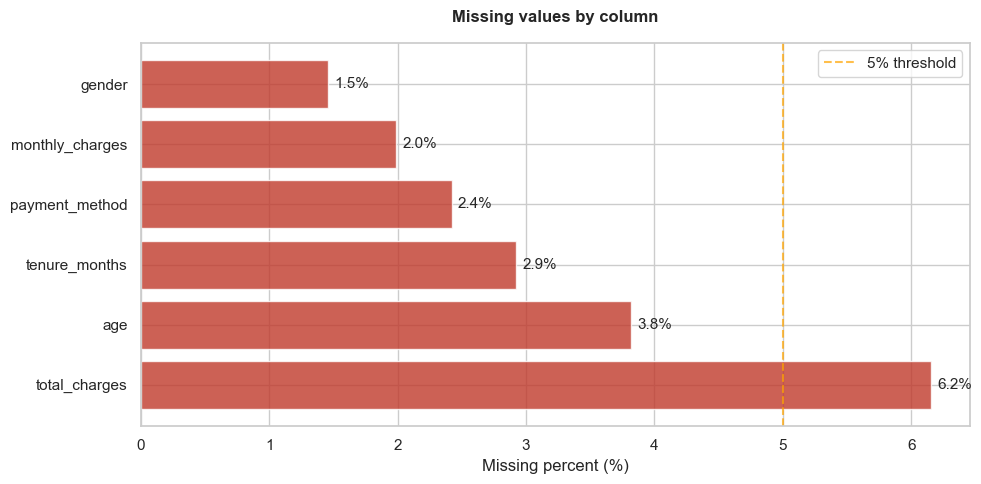

Plot saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

missing_plot = missing_df[missing_df["Missing"] > 0]
bars = ax.barh(missing_plot.index, missing_plot["Percent"],
               color="#c92e1d", alpha=0.8)

# Add values to bars
for bar, val in zip(bars, missing_plot["Percent"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=11)

ax.set_xlabel("Missing percent (%)")
ax.set_title("Missing values by column", fontweight="bold", pad=15)
ax.axvline(x=5, color="orange", linestyle="--",
           alpha=0.7, label="5% threshold")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / "01_missing_values.png",
            bbox_inches="tight")
plt.show()
print("Plot saved.")

#### Key Findings
- Only `total_charges` is above the 5% missing threshold.
- Most other columns have missing rates below 4%.

## Target Distribution
Check class balance for churn.

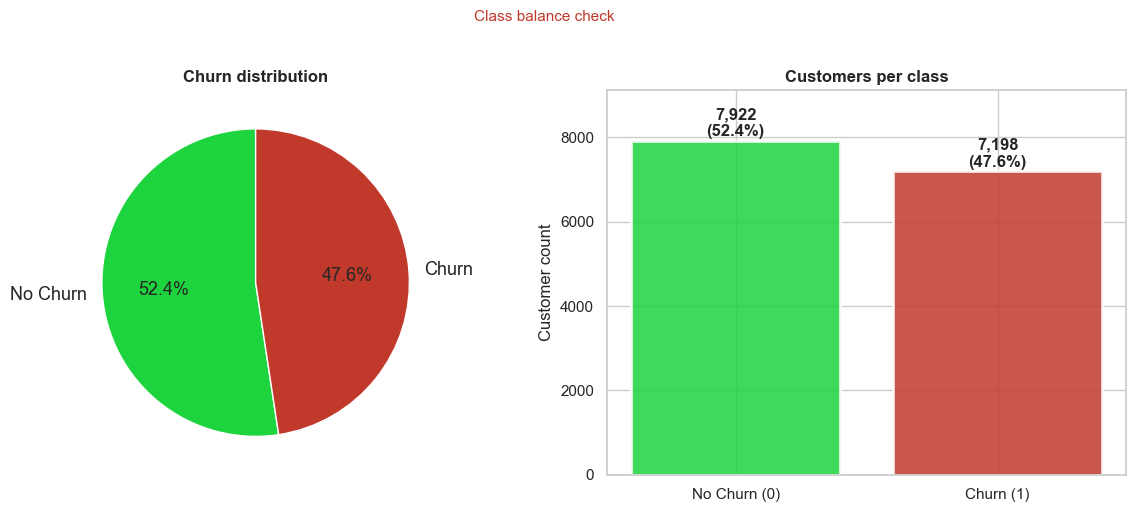

Churn rate: 47.6%
Class balance is close to 50/50, but accuracy alone is not enough.
Use AUC-ROC, F1, PR-AUC, and recall.


In [18]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = ["#1dd33e", '#c0392b']
ax1.pie(churn_counts, labels=['No Churn', 'Churn'],
        colors=colors, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 13})
ax1.set_title('Churn distribution', fontweight='bold')

# Bar chart with annotations
bars = ax2.bar(['No Churn (0)', 'Churn (1)'],
               churn_counts.values, color=colors, alpha=0.85,
               edgecolor='white', linewidth=2)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 100,
             f'{count:,}\n({pct:.1f}%)',
             ha='center', fontweight='bold', fontsize=12)

ax2.set_title('Customers per class', fontweight='bold')
ax2.set_ylabel('Customer count')
ax2.set_ylim(0, max(churn_counts.values) * 1.15)

plt.suptitle('Class balance check',
             fontsize=11, color='#c0392b', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '02_churn_distribution.png',
            bbox_inches='tight')
plt.show()

print(f"Churn rate: {churn_pct[1]:.1f}%")
print("Class balance is close to 50/50, but accuracy alone is not enough.")
print("Use AUC-ROC, F1, PR-AUC, and recall.")

#### Key Findings
- Churn rate is 47.6% (7,198 churn vs 7,922 no churn).
- Class balance is close to 50/50, so baseline accuracy is not very informative by itself.

## Churn by Categorical Features
Compare churn rate across key categories.

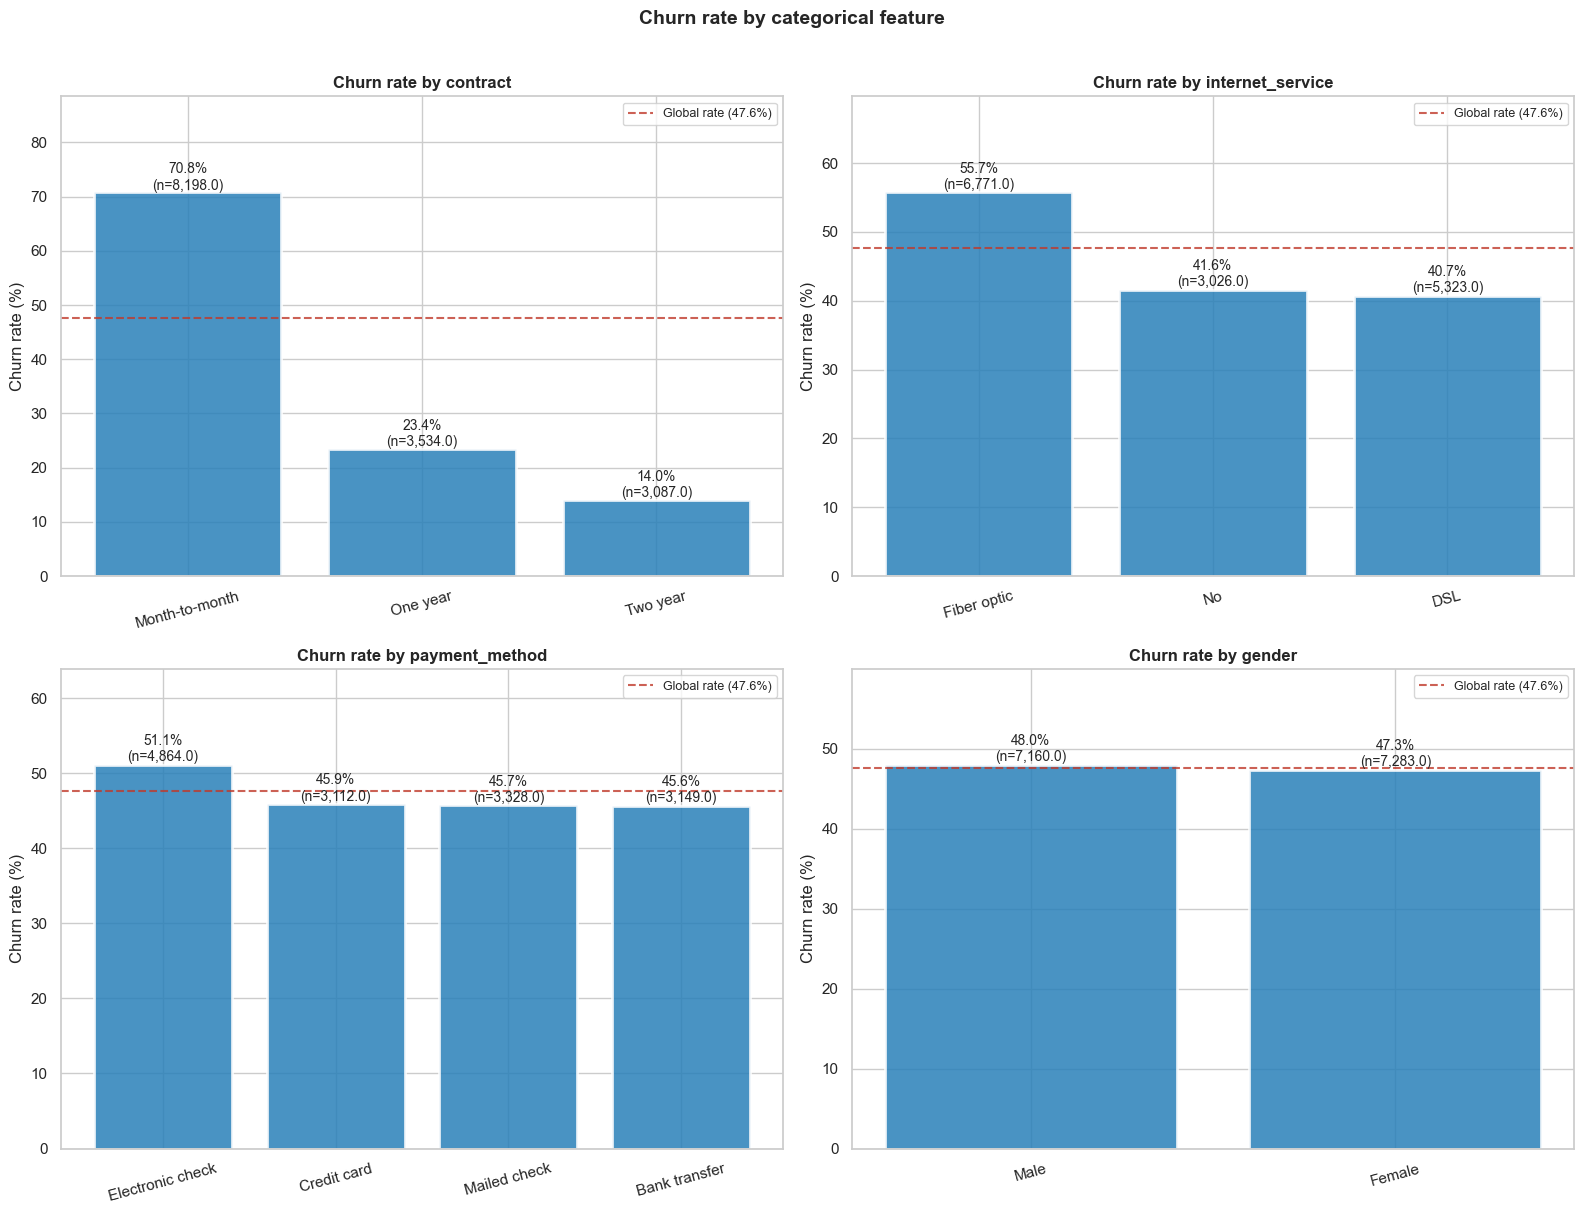

In [6]:
cat_cols = ['contract', 'internet_service',
            'payment_method', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Compute churn rate by category
    # Ignore non-standard values for now
    standard_vals = {
        'contract': ['Month-to-month', 'One year', 'Two year'],
        'internet_service': ['DSL', 'Fiber optic', 'No'],
        'payment_method': ['Electronic check', 'Mailed check',
                           'Bank transfer', 'Credit card'],
        'gender': ['Male', 'Female']
    }
    mask = df[col].isin(standard_vals[col])
    temp = df[mask].groupby(col)['churn'].agg(['mean', 'count'])
    temp['mean'] = temp['mean'] * 100
    temp = temp.sort_values('mean', ascending=False)

    bars = axes[i].bar(temp.index, temp['mean'],
                       color='#2980b9', alpha=0.85,
                       edgecolor='white', linewidth=2)

    # Annotations
    for bar, (idx, row) in zip(bars, temp.iterrows()):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{row['mean']:.1f}%\n(n={row['count']:,})",
            ha='center', fontsize=10
        )

    # Reference line = global rate
    global_rate = df['churn'].mean() * 100
    axes[i].axhline(y=global_rate, color='#c0392b',
                    linestyle='--', alpha=0.8,
                    label=f'Global rate ({global_rate:.1f}%)')

    axes[i].set_title(f'Churn rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].set_ylim(0, temp['mean'].max() * 1.25)
    axes[i].legend(fontsize=9)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn rate by categorical feature',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '03_churn_by_category.png',
            bbox_inches='tight')
plt.show()

#### Key Findings
- Highest churn by contract: Month-to-month at 70.8%.
- Fiber optic has the highest churn among internet services at 55.7%.
- Electronic check shows the highest churn among payment methods at 51.1%.

## Numeric Features vs Churn
Compare numeric distributions for churn and non-churn.

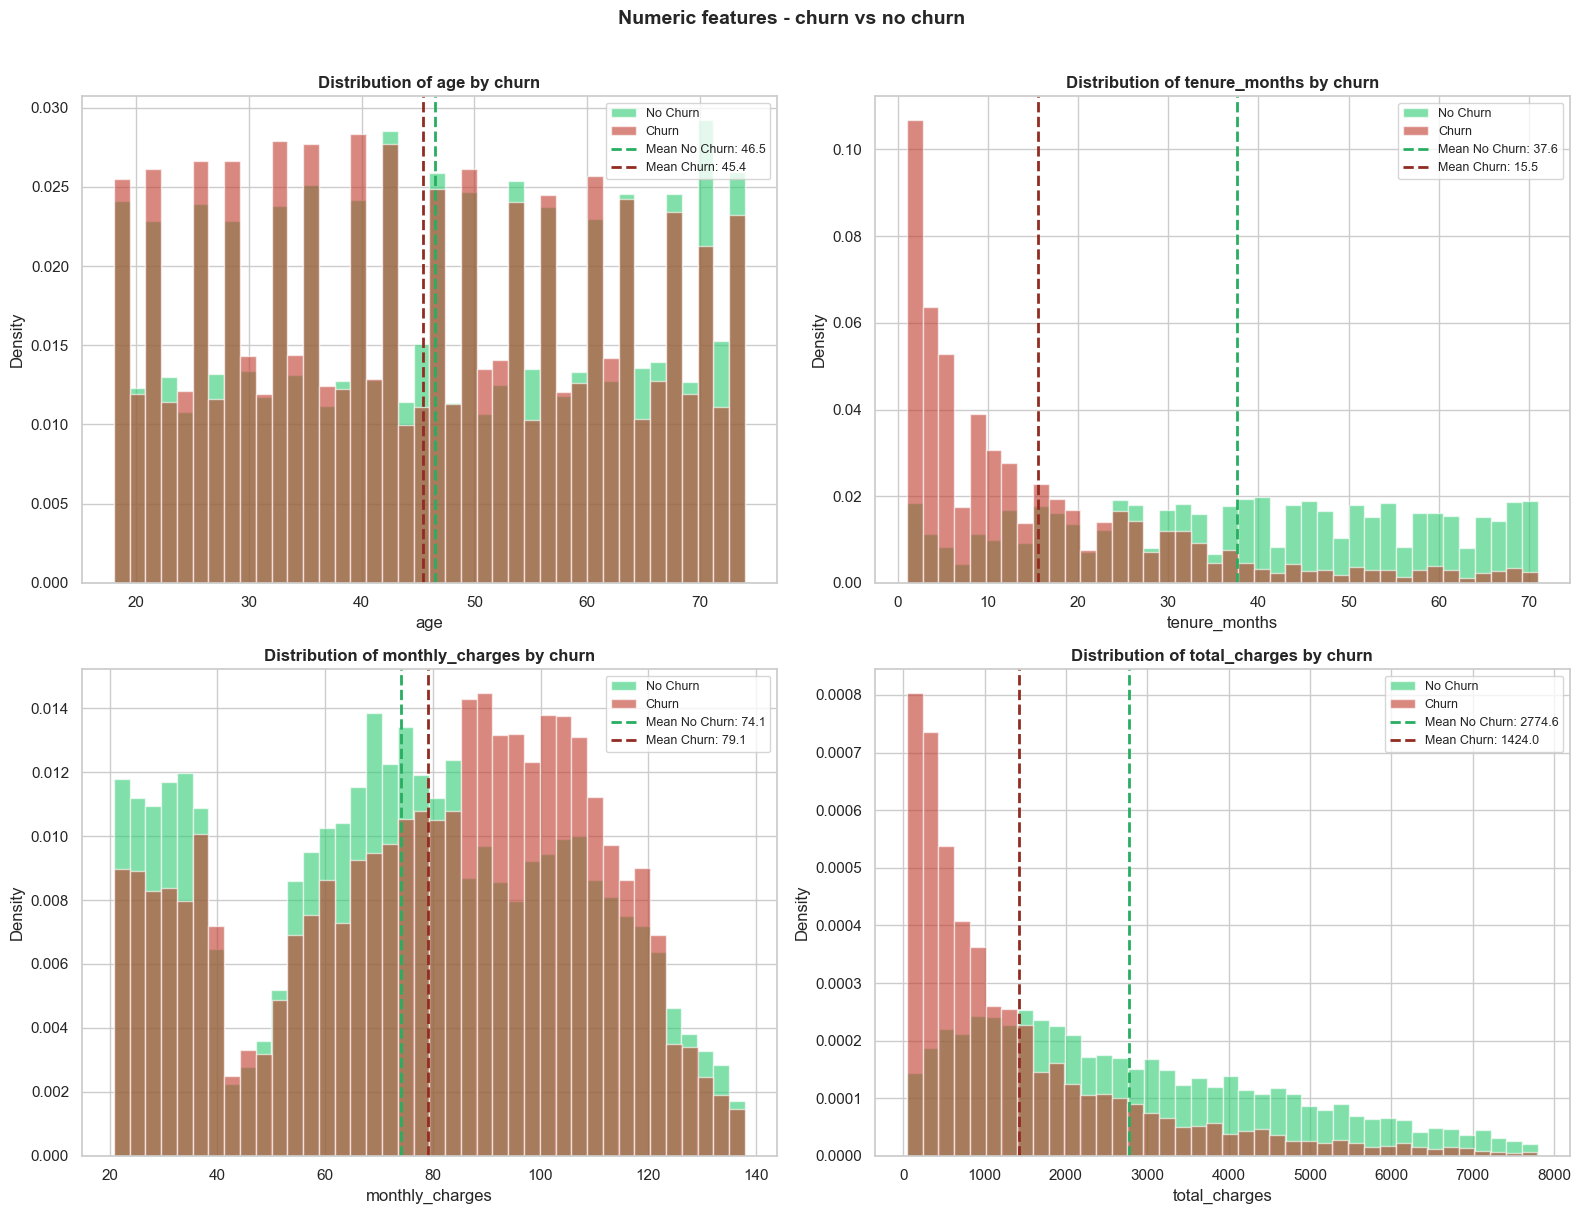

In [7]:
num_cols = ['age', 'tenure_months',
            'monthly_charges', 'total_charges']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Trim outliers for visualization only
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    temp = df[(df[col] >= q1) & (df[col] <= q99)]

    no_churn = temp[temp['churn'] == 0][col].dropna()
    churn = temp[temp['churn'] == 1][col].dropna()

    axes[i].hist(no_churn, bins=40, alpha=0.6,
                 color='#2ecc71', label='No Churn', density=True)
    axes[i].hist(churn, bins=40, alpha=0.6,
                 color='#c0392b', label='Churn', density=True)

    # Means
    axes[i].axvline(no_churn.mean(), color='#27ae60',
                    linestyle='--', linewidth=2,
                    label=f'Mean No Churn: {no_churn.mean():.1f}')
    axes[i].axvline(churn.mean(), color='#922b21',
                    linestyle='--', linewidth=2,
                    label=f'Mean Churn: {churn.mean():.1f}')

    axes[i].set_title(f'Distribution of {col} by churn',
                      fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Numeric features - churn vs no churn',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_numeric_distributions.png',
            bbox_inches='tight')
plt.show()

#### Key Findings
- Churners have much shorter tenure on average (16.1 months vs 38.0).
- Churners have higher monthly charges (+4.29) but much lower total charges (-1,424.82).

## Outlier Review
Use boxplots and IQR counts to spot outliers.

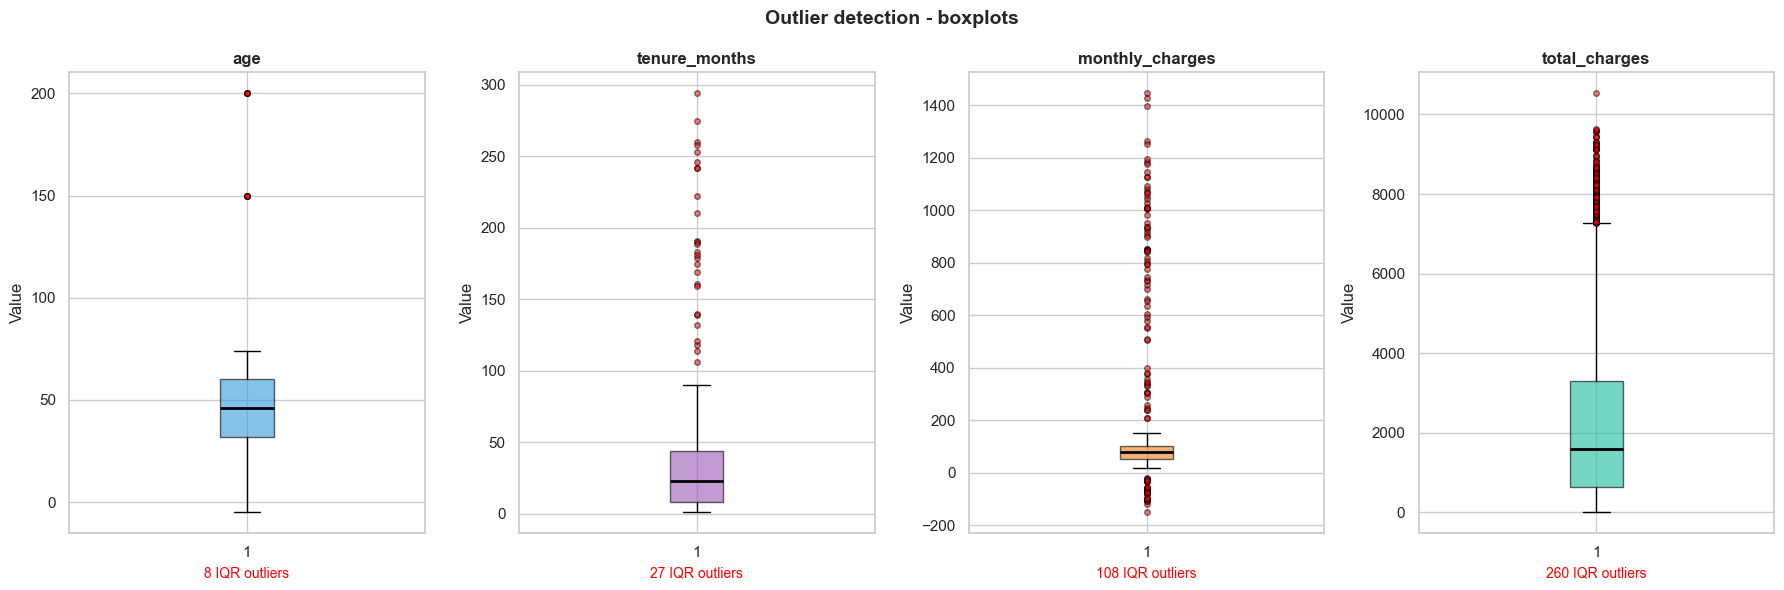

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
num_cols = ['age', 'tenure_months',
            'monthly_charges', 'total_charges']
colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']

for i, (col, color) in enumerate(zip(num_cols, colors)):
    data = df[col].dropna()
    axes[i].boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=4, alpha=0.5))
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Value')

    # Count outliers using IQR
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    axes[i].set_xlabel(f'{n_out} IQR outliers',
                       color='red', fontsize=10)

plt.suptitle('Outlier detection - boxplots',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '05_outliers_boxplot.png',
            bbox_inches='tight')
plt.show()

#### Key Findings
- Most IQR outliers appear in `total_charges` (260) and `monthly_charges` (108).
- `age` and `tenure_months` have very few outliers (8 and 27).

## Correlation Analysis
Review correlations and churn drivers.

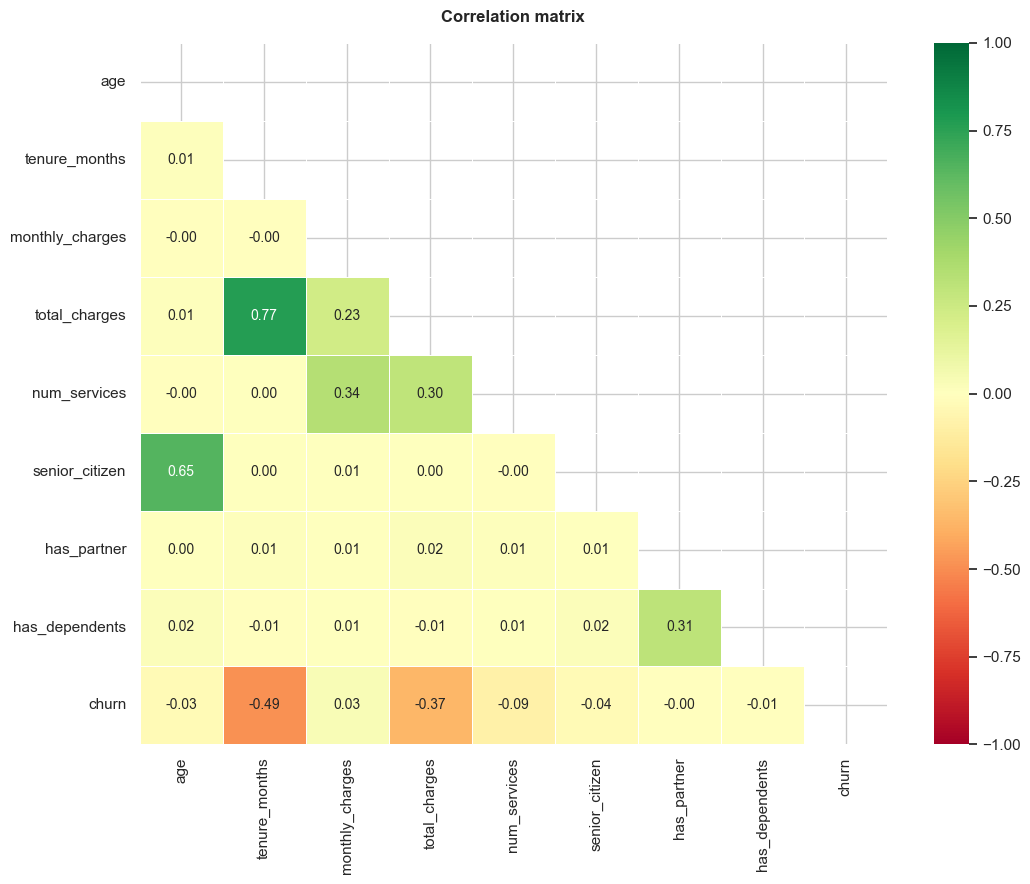

-- Correlations with churn (sorted) --
  tenure_months          -0.485  lower risk
  total_charges          -0.366  lower risk
  num_services           -0.091  lower risk
  senior_citizen         -0.037  lower risk
  monthly_charges        +0.034  higher risk
  age                    -0.034  lower risk
  has_dependents         -0.006  lower risk
  has_partner            -0.002  lower risk


In [9]:
# Select numeric columns for correlation
numeric_df = df[['age', 'tenure_months', 'monthly_charges',
                 'total_charges', 'num_services',
                 'senior_citizen', 'has_partner',
                 'has_dependents', 'churn']].copy()

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            annot_kws={'size': 10})

ax.set_title('Correlation matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '06_correlation_matrix.png',
            bbox_inches='tight')
plt.show()

# Correlations with churn only
print("-- Correlations with churn (sorted) --")
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs,
                                                             ascending=False)
for feat, val in churn_corr.items():
    direction = "higher risk" if val > 0 else "lower risk"
    print(f"  {feat:<22} {val:>+.3f}  {direction}")

#### Key Findings
- Strongest churn correlation is with `tenure_months` (-0.485).
- `total_charges` is also negatively correlated with churn (-0.366).

## Executive Summary
Highlight key churn signals and data quality issues.

In [10]:
print("=" * 55)
print("  KEY INSIGHTS ")
print("=" * 55)

# Insight 1: churn by contract
mask = df['contract'].isin(['Month-to-month', 'One year', 'Two year'])
contract_churn = df[mask].groupby('contract')['churn'].mean() * 100
print("\n1. CONTRACT:")
for c, r in contract_churn.sort_values(ascending=False).items():
    print(f"   {c:<22} -> {r:.1f}% churn")

# Insight 2: new customers
new = df[df['tenure_months'] <= 6]['churn'].mean() * 100
old = df[df['tenure_months'] > 36]['churn'].mean() * 100
print("\n2. TENURE:")
print(f"   Customers <= 6 months  -> {new:.1f}% churn")
print(f"   Customers > 36 months  -> {old:.1f}% churn")

# Insight 3: fiber without support
mask_fiber_no = ((df['internet_service'] == 'Fiber optic') &
                  (df['tech_support'] == 'No'))
mask_fiber_yes = ((df['internet_service'] == 'Fiber optic') &
                   (df['tech_support'] == 'Yes'))
fiber_no = df[mask_fiber_no]['churn'].mean() * 100
fiber_yes = df[mask_fiber_yes]['churn'].mean() * 100
print("\n3. FIBER OPTIC:")
print(f"   No tech support   -> {fiber_no:.1f}% churn")
print(f"   With tech support -> {fiber_yes:.1f}% churn")

# Insight 4: services
for n in range(4):
    r = df[df['num_services'] == n]['churn'].mean() * 100
    print(f"\n4. {n} service(s)      -> {r:.1f}% churn" if n == 0
          else f"   {n} service(s)      -> {r:.1f}% churn")

print("\n=" * 55)
print("  DATA QUALITY ISSUES - TO FIX IN CLEANING")
print("=" * 55)
print(f"\nMissing values       : {df.isnull().sum().sum()} cells")
print(f"Outliers monthly_chg  : "
      f"{(df['monthly_charges'].dropna() > 300).sum()} rows > 300")
print(f"Outliers age          : "
      f"{((df['age'].dropna() < 18) | (df['age'].dropna() > 100)).sum()} impossible rows")
print(f"Unique gender values  : "
      f"{df['gender'].nunique()} (expected: 2)")
print(f"Potential duplicates  : "
      f"{df.duplicated(subset=['tenure_months','monthly_charges','contract']).sum()}")

  KEY INSIGHTS 

1. CONTRACT:
   Month-to-month         -> 70.8% churn
   One year               -> 23.4% churn
   Two year               -> 14.0% churn

2. TENURE:
   Customers <= 6 months  -> 84.2% churn
   Customers > 36 months  -> 15.3% churn

3. FIBER OPTIC:
   No tech support   -> 67.2% churn
   With tech support -> 35.8% churn

4. 0 service(s)      -> 50.3% churn
   1 service(s)      -> 51.0% churn
   2 service(s)      -> 41.4% churn
   3 service(s)      -> 30.4% churn

=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
  DATA QUALITY ISSUES - TO FIX IN CLEANING

Missing values       : 2838 cells
Outliers monthly_chg  : 67 rows > 300
Outliers age          : 30 impossible rows
Unique gender values  : 11 (expected: 2)
Potential duplicates  : 318


#### Key Findings
- Contract length matters: month-to-month churn is 70.8% vs 14.0% for two-year.
- Early tenure is high risk: <= 6 months churn is 84.2% vs 15.3% for > 36 months.
- Data quality issues: 2,838 missing cells, 11 unique `gender` values, and 318 potential duplicates.

## Categorical Noise Review
Find non-standard category values.

  CATEGORICAL NOISE ANALYSIS


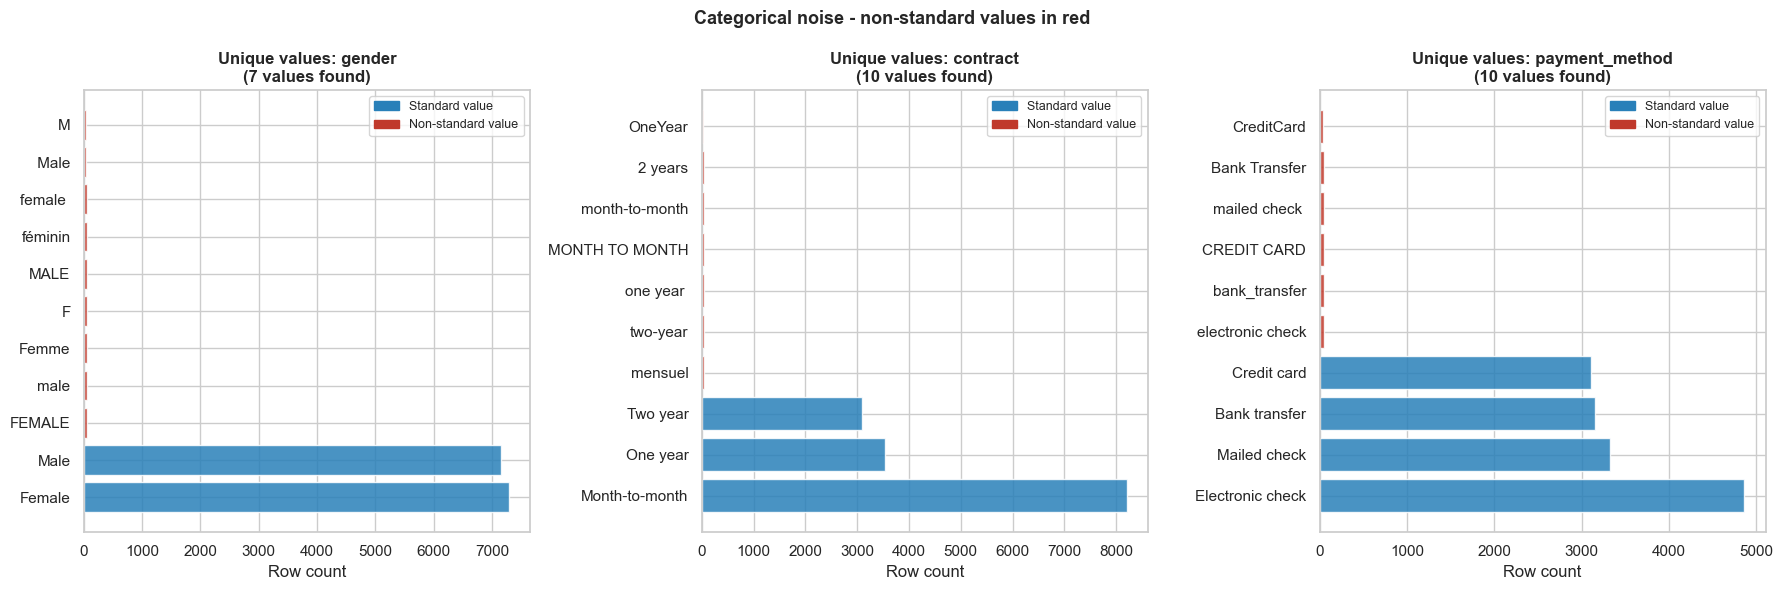

  gender               :  456 non-standard rows (3.0%)
  contract             :  301 non-standard rows (2.0%)
  payment_method       :  301 non-standard rows (2.0%)


In [11]:
print("=" * 55)
print("  CATEGORICAL NOISE ANALYSIS")
print("=" * 55)

cat_dirty = ['gender', 'contract', 'payment_method']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_dirty):
    value_counts = df[col].value_counts()
    colors_bar = ['#c0392b' if v not in [
        'Male', 'Female',
        'Month-to-month', 'One year', 'Two year',
        'Electronic check', 'Mailed check',
        'Bank transfer', 'Credit card'
    ] else '#2980b9' for v in value_counts.index]

    axes[i].barh(value_counts.index.astype(str),
                 value_counts.values,
                 color=colors_bar, alpha=0.85)
    axes[i].set_title(f'Unique values: {col}\n'
                      f'({value_counts.nunique()} values found)',
                      fontweight='bold')
    axes[i].set_xlabel('Row count')

    # Manual legend
    from matplotlib.patches import Patch
    legend = [Patch(color='#2980b9', label='Standard value'),
              Patch(color='#c0392b', label='Non-standard value')]
    axes[i].legend(handles=legend, fontsize=9)

plt.suptitle('Categorical noise - non-standard values in red',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '07_categorical_noise.png',
            bbox_inches='tight')
plt.show()

# Quantify
for col in cat_dirty:
    standards = {
        'gender': ['Male', 'Female'],
        'contract': ['Month-to-month', 'One year', 'Two year'],
        'payment_method': ['Electronic check', 'Mailed check',
                           'Bank transfer', 'Credit card']
    }
    noisy = (~df[col].isin(standards[col]) & df[col].notna()).sum()
    pct = noisy / len(df) * 100
    print(f"  {col:<20} : {noisy:>4} non-standard rows ({pct:.1f}%)")

#### Key Findings
- Non-standard values exist in `gender` (456 rows, 3.0%).
- `contract` and `payment_method` each have 301 non-standard rows (~2.0%).

## Logical Consistency Checks
Detect rule violations and potential duplicates.

  LOGICAL INCONSISTENCIES IN DATA

Inconsistency 1 - No internet but security=Yes:
  82 rows (0.54%)
  Churn rate in this group: 48.8%

Inconsistency 2 - Total charges = 0 but tenure > 24 months:
  40 rows (0.26%)
  Mean tenure in this group: 47.7 months

Inconsistency 3 - Partial duplicates detected:
  414 potentially duplicated rows
  (2.74% of the dataset)


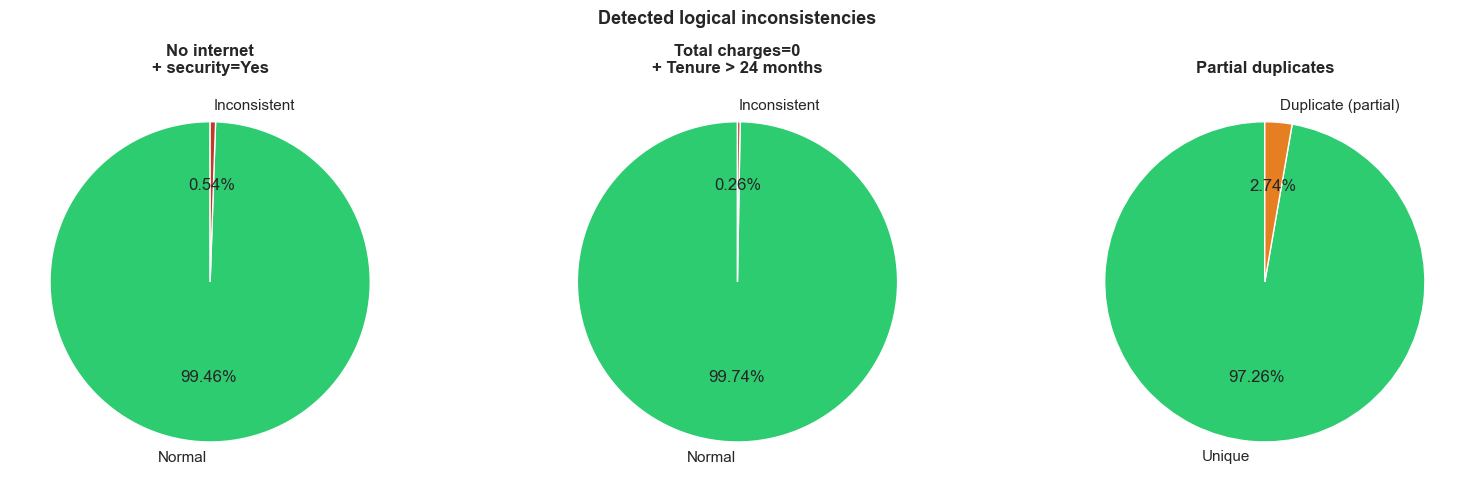

In [12]:
print("=" * 55)
print("  LOGICAL INCONSISTENCIES IN DATA")
print("=" * 55)

# Inconsistency 1: no internet but online_security = Yes
inc1 = df[
    (df['internet_service'] == 'No') &
    (df['online_security'] == 'Yes')
]
print("\nInconsistency 1 - No internet but security=Yes:")
print(f"  {len(inc1)} rows ({len(inc1)/len(df)*100:.2f}%)")
print(f"  Churn rate in this group: "
      f"{inc1['churn'].mean()*100:.1f}%")

# Inconsistency 2: total_charges = 0 with high tenure
inc2 = df[
    (df['total_charges'] == 0) &
    (df['tenure_months'] > 24)
]
print("\nInconsistency 2 - Total charges = 0 but tenure > 24 months:")
print(f"  {len(inc2)} rows ({len(inc2)/len(df)*100:.2f}%)")
print(f"  Mean tenure in this group: "
      f"{inc2['tenure_months'].mean():.1f} months")

# Inconsistency 3: partial duplicates
dupes = df[df.duplicated(
    subset=['tenure_months', 'monthly_charges',
            'contract', 'internet_service'],
    keep=False
)]
print("\nInconsistency 3 - Partial duplicates detected:")
print(f"  {len(dupes)} potentially duplicated rows")
print(f"  ({len(dupes)/len(df)*100:.2f}% of the dataset)")

# Visualization of the 3 inconsistencies
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1
labels = ['Normal', 'Inconsistent']
sizes = [len(df) - len(inc1), len(inc1)]
axes[0].pie(sizes, labels=labels, autopct='%1.2f%%',
            colors=['#2ecc71', '#c0392b'], startangle=90)
axes[0].set_title('No internet\n+ security=Yes', fontweight='bold')

# Plot 2
labels2 = ['Normal', 'Inconsistent']
sizes2 = [len(df) - len(inc2), len(inc2)]
axes[1].pie(sizes2, labels=labels2, autopct='%1.2f%%',
            colors=['#2ecc71', '#c0392b'], startangle=90)
axes[1].set_title('Total charges=0\n+ Tenure > 24 months',
                  fontweight='bold')

# Plot 3
labels3 = ['Unique', 'Duplicate (partial)']
sizes3 = [len(df) - len(dupes), len(dupes)]
axes[2].pie(sizes3, labels=labels3, autopct='%1.2f%%',
            colors=['#2ecc71', '#e67e22'], startangle=90)
axes[2].set_title('Partial duplicates', fontweight='bold')

plt.suptitle('Detected logical inconsistencies',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '08_logical_inconsistencies.png',
            bbox_inches='tight')
plt.show()

#### Key Findings
- 82 rows show `online_security = Yes` while `internet_service = No`.
- 40 rows have `total_charges = 0` with tenure > 24 months.
- 414 rows are potential partial duplicates.

## Bivariate Relationships
Inspect pairwise relationships colored by churn.

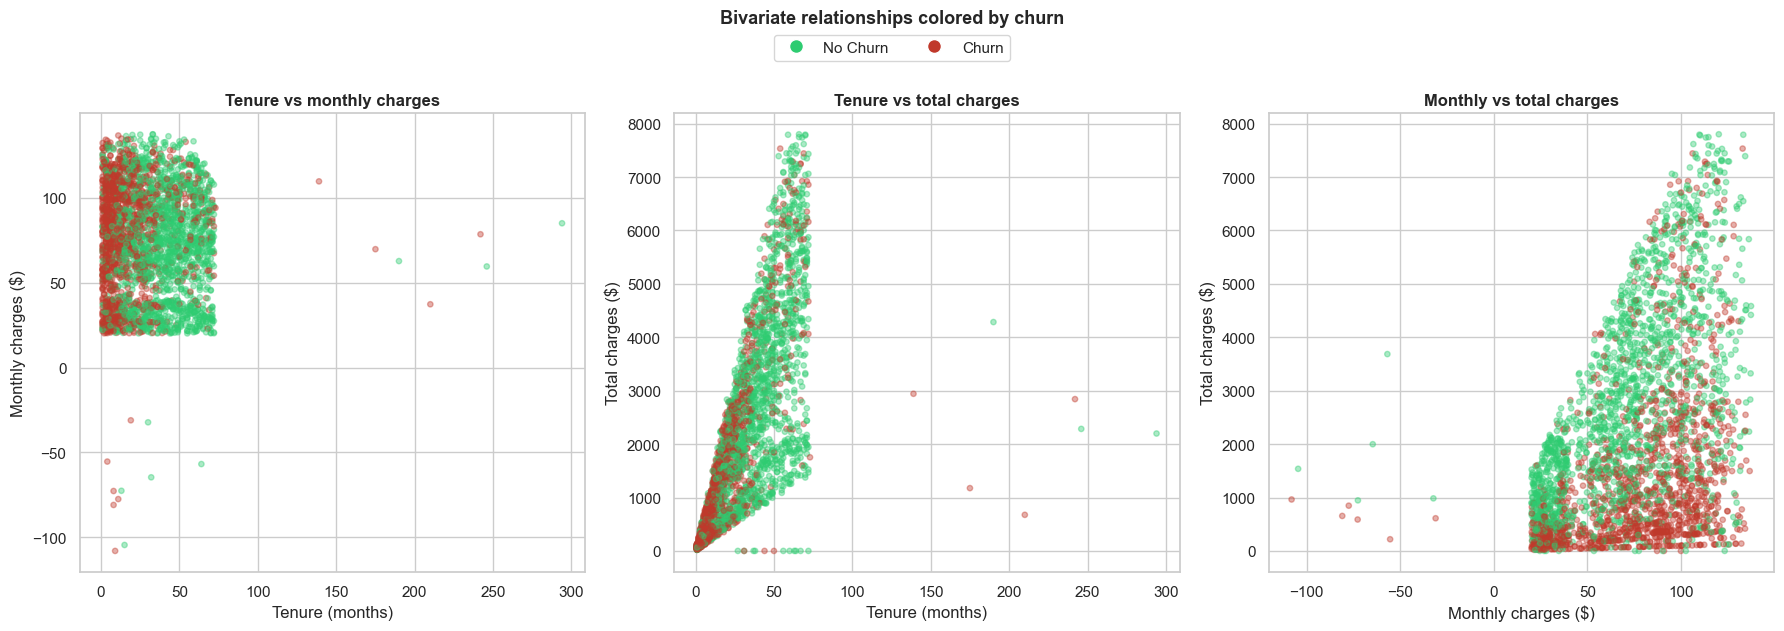

Key observation: strong multicollinearity between
total_charges and tenure_months x monthly_charges
-> Consider in feature engineering


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Clean for visualization
q99_mc = df['monthly_charges'].quantile(0.99)
q99_tc = df['total_charges'].quantile(0.99)
viz_df = df[
    (df['monthly_charges'] <= q99_mc) &
    (df['total_charges'] <= q99_tc) &
    df['monthly_charges'].notna() &
    df['total_charges'].notna() &
    df['tenure_months'].notna()
].sample(n=3000, random_state=42)

colors_scatter = viz_df['churn'].map({0: '#2ecc71', 1: '#c0392b'})

# Plot 1: tenure vs monthly_charges
axes[0].scatter(viz_df['tenure_months'],
                viz_df['monthly_charges'],
                c=colors_scatter, alpha=0.4, s=15)
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Monthly charges ($)')
axes[0].set_title('Tenure vs monthly charges', fontweight='bold')

# Plot 2: tenure vs total_charges
axes[1].scatter(viz_df['tenure_months'],
                viz_df['total_charges'],
                c=colors_scatter, alpha=0.4, s=15)
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Total charges ($)')
axes[1].set_title('Tenure vs total charges', fontweight='bold')

# Plot 3: monthly vs total
axes[2].scatter(viz_df['monthly_charges'],
                viz_df['total_charges'],
                c=colors_scatter, alpha=0.4, s=15)
axes[2].set_xlabel('Monthly charges ($)')
axes[2].set_ylabel('Total charges ($)')
axes[2].set_title('Monthly vs total charges', fontweight='bold')

# Shared legend
from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#2ecc71', markersize=10, label='No Churn'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#c0392b', markersize=10, label='Churn')
]
fig.legend(handles=legend, loc='upper center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Bivariate relationships colored by churn',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIGURES_PATH / '09_bivariate_scatter.png',
            bbox_inches='tight')
plt.show()

print("Key observation: strong multicollinearity between")
print("total_charges and tenure_months x monthly_charges")
print("-> Consider in feature engineering")

#### Key Findings
- `total_charges` is strongly correlated with `tenure_months` (r = 0.768).
- Correlation between `monthly_charges` and `total_charges` is weaker (r = 0.234).

## Outlier Impact on Summary Stats
See how outliers shift mean vs median.

  OUTLIER IMPACT ON SUMMARY STATS

monthly_charges:
  IQR outliers    : 108 rows
  Mean distortion : 4.1%

age:
  IQR outliers    : 8 rows
  Mean distortion : 0.2%

tenure_months:
  IQR outliers    : 27 rows
  Mean distortion : 1.1%


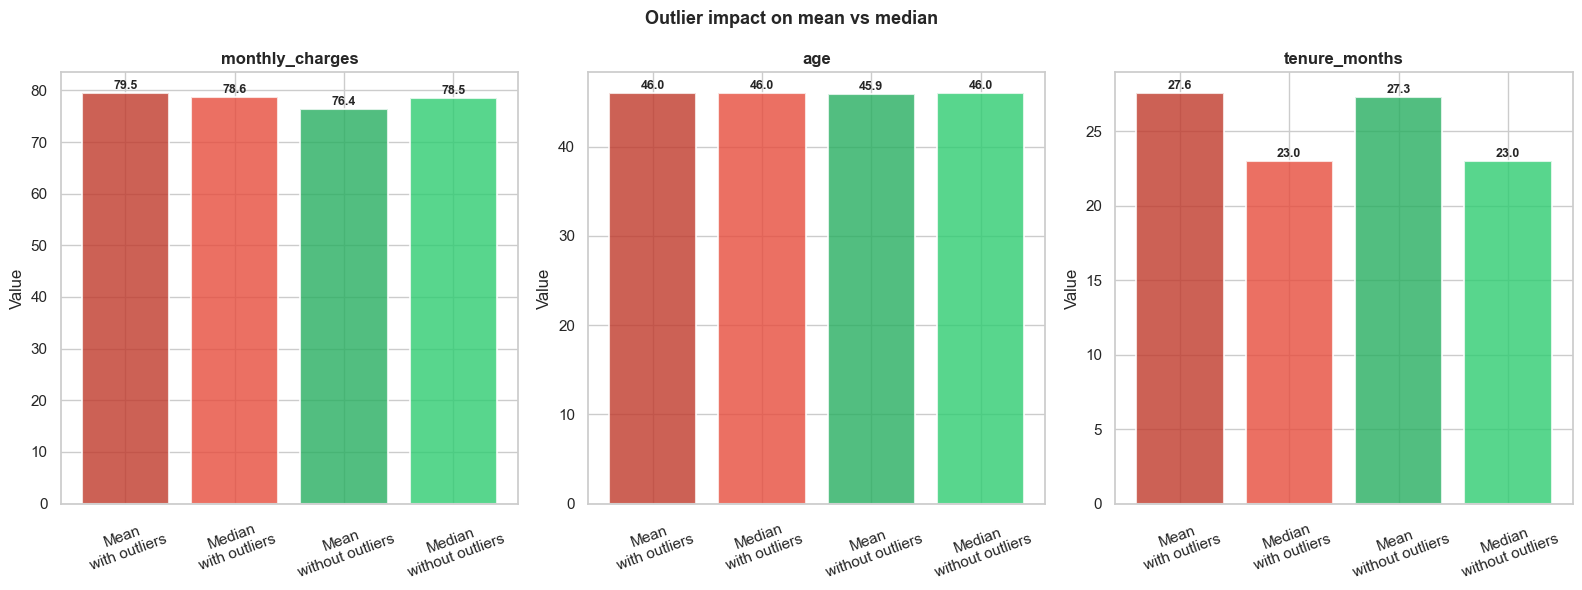

In [14]:
print("=" * 60)
print("  OUTLIER IMPACT ON SUMMARY STATS")
print("=" * 60)

cols_to_analyze = ['monthly_charges', 'age', 'tenure_months']
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(cols_to_analyze):
    data = df[col].dropna()

    # With outliers
    mean_with = data.mean()
    median_with = data.median()

    # IQR bounds
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    data_clean = data[(data >= lower) & (data <= upper)]

    mean_without = data_clean.mean()
    median_without = data_clean.median()

    # Visualization
    categories = ['Mean\nwith outliers',
                  'Median\nwith outliers',
                  'Mean\nwithout outliers',
                  'Median\nwithout outliers']
    values = [mean_with, median_with,
              mean_without, median_without]
    bar_colors = ['#c0392b', '#e74c3c', '#27ae60', '#2ecc71']

    bars = axes[i].bar(categories, values,
                       color=bar_colors, alpha=0.8,
                       edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(values) * 0.01,
                     f'{val:.1f}',
                     ha='center', fontsize=9, fontweight='bold')

    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=20)

    n_outliers = len(data) - len(data_clean)
    print(f"\n{col}:")
    print(f"  IQR outliers    : {n_outliers} rows")
    print(f"  Mean distortion : "
          f"{abs(mean_with - mean_without) / mean_without * 100:.1f}%")

plt.suptitle('Outlier impact on mean vs median',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '10_outlier_impact.png',
            bbox_inches='tight')
plt.show()

#### Key Findings
- `monthly_charges` mean shifts by about 4.1% after removing outliers.
- `age` and `tenure_months` are barely affected (<= 1.1% distortion).

## Accuracy Baseline Trap
Show why accuracy alone is misleading.

  WHY ACCURACY IS MISLEADING HERE

If we always predict 'No Churn':
  Accuracy          : 52.4%  <- looks good
  Recall (churners) : 0.0%     <- detects zero churners
  F1 score          : 0.0%     <- useless

Conclusion: accuracy alone is not enough.
Use: AUC-ROC, F1, PR-AUC, Recall


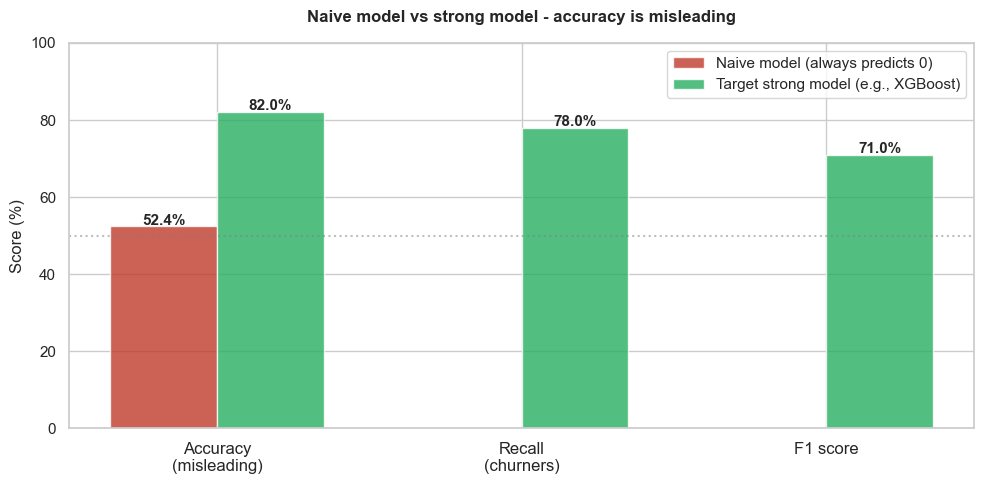

In [15]:
print("=" * 55)
print("  WHY ACCURACY IS MISLEADING HERE")
print("=" * 55)

churn_rate = df['churn'].mean()
no_churn_rate = 1 - churn_rate

print("\nIf we always predict 'No Churn':")
print(f"  Accuracy          : {no_churn_rate*100:.1f}%  <- looks good")
print(f"  Recall (churners) : 0.0%     <- detects zero churners")
print(f"  F1 score          : 0.0%     <- useless")
print("\nConclusion: accuracy alone is not enough.")
print("Use: AUC-ROC, F1, PR-AUC, Recall")

# Clear visualization
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['Accuracy\n(misleading)', 'Recall\n(churners)', 'F1 score']
baseline_vals = [no_churn_rate * 100, 0, 0]
good_model_vals = [82.0, 78.0, 71.0]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width / 2, baseline_vals, width,
               label='Naive model (always predicts 0)',
               color='#c0392b', alpha=0.8)
bars2 = ax.bar(x + width / 2, good_model_vals, width,
               label='Target strong model (e.g., XGBoost)',
               color='#27ae60', alpha=0.8)

for bar, val in zip(bars1, baseline_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center',
                fontsize=11, fontweight='bold')

for bar, val in zip(bars2, good_model_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center',
            fontsize=11, fontweight='bold')

ax.set_ylabel('Score (%)')
ax.set_title('Naive model vs strong model - accuracy is misleading',
             fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_PATH / '11_accuracy_trap.png',
            bbox_inches='tight')
plt.show()

#### Key Findings
- Churn rate is 47.6%, so a naive model gets 52.4% accuracy by predicting all non-churn.
- Accuracy alone can hide zero recall for churners.